In [12]:
"""
Automatically reloads libraries and utilities every time a cell is run
"""
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.PSF_helpers import *
from utils.Plot_helpers import *
from utils.Zernike_helpers import *
from utils.Booth_helpers import *
from utils.Phase_diversity_helpers import *

In [24]:
#minor style things to make the figures look nice
plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 12
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300
import os
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

In [25]:
N_order = 1              # 3 for 3P, 2 for 2P
lambd = 5.32e-4             # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.2            # Numerical aperture
focal = 7.2                    # Focal length of objective (Olympus) [mm]
mag = np.nan                   # Magnification rate from input to objective
w_0 = np.nan                 # mm
alpha = np.arcsin(num_apt / n)

#106.5 microns
L_ffp = 0.1065
#512 x 512
grid_ffp = 512
grid = Centered_Square_Grid(L_ffp, grid_ffp, 0)
#CONJUGATE BFP LENGTH
grid_bfp = grid_ffp
L_bfp = (lambd * focal * grid_bfp) / L_ffp
microscope = Microscope(N_order, lambd, n, num_apt, focal, mag, w_0, L_bfp, grid_bfp)
x, y = grid.get_xy()
x_bfp = x * (L_bfp/ L_ffp)
y_bfp = y * (L_bfp/ L_ffp)

In [59]:
c_true = np.load("gamma_results/c_true_3p.npy")
c_converged = np.load("gamma_results/c_converged_3p.npy")

SNR_vals = [5, 10, 20]
gamma_vals = [10**(-x) for x in range(1, 31)]
num_samples = 1

modes = get_johnson_modes()

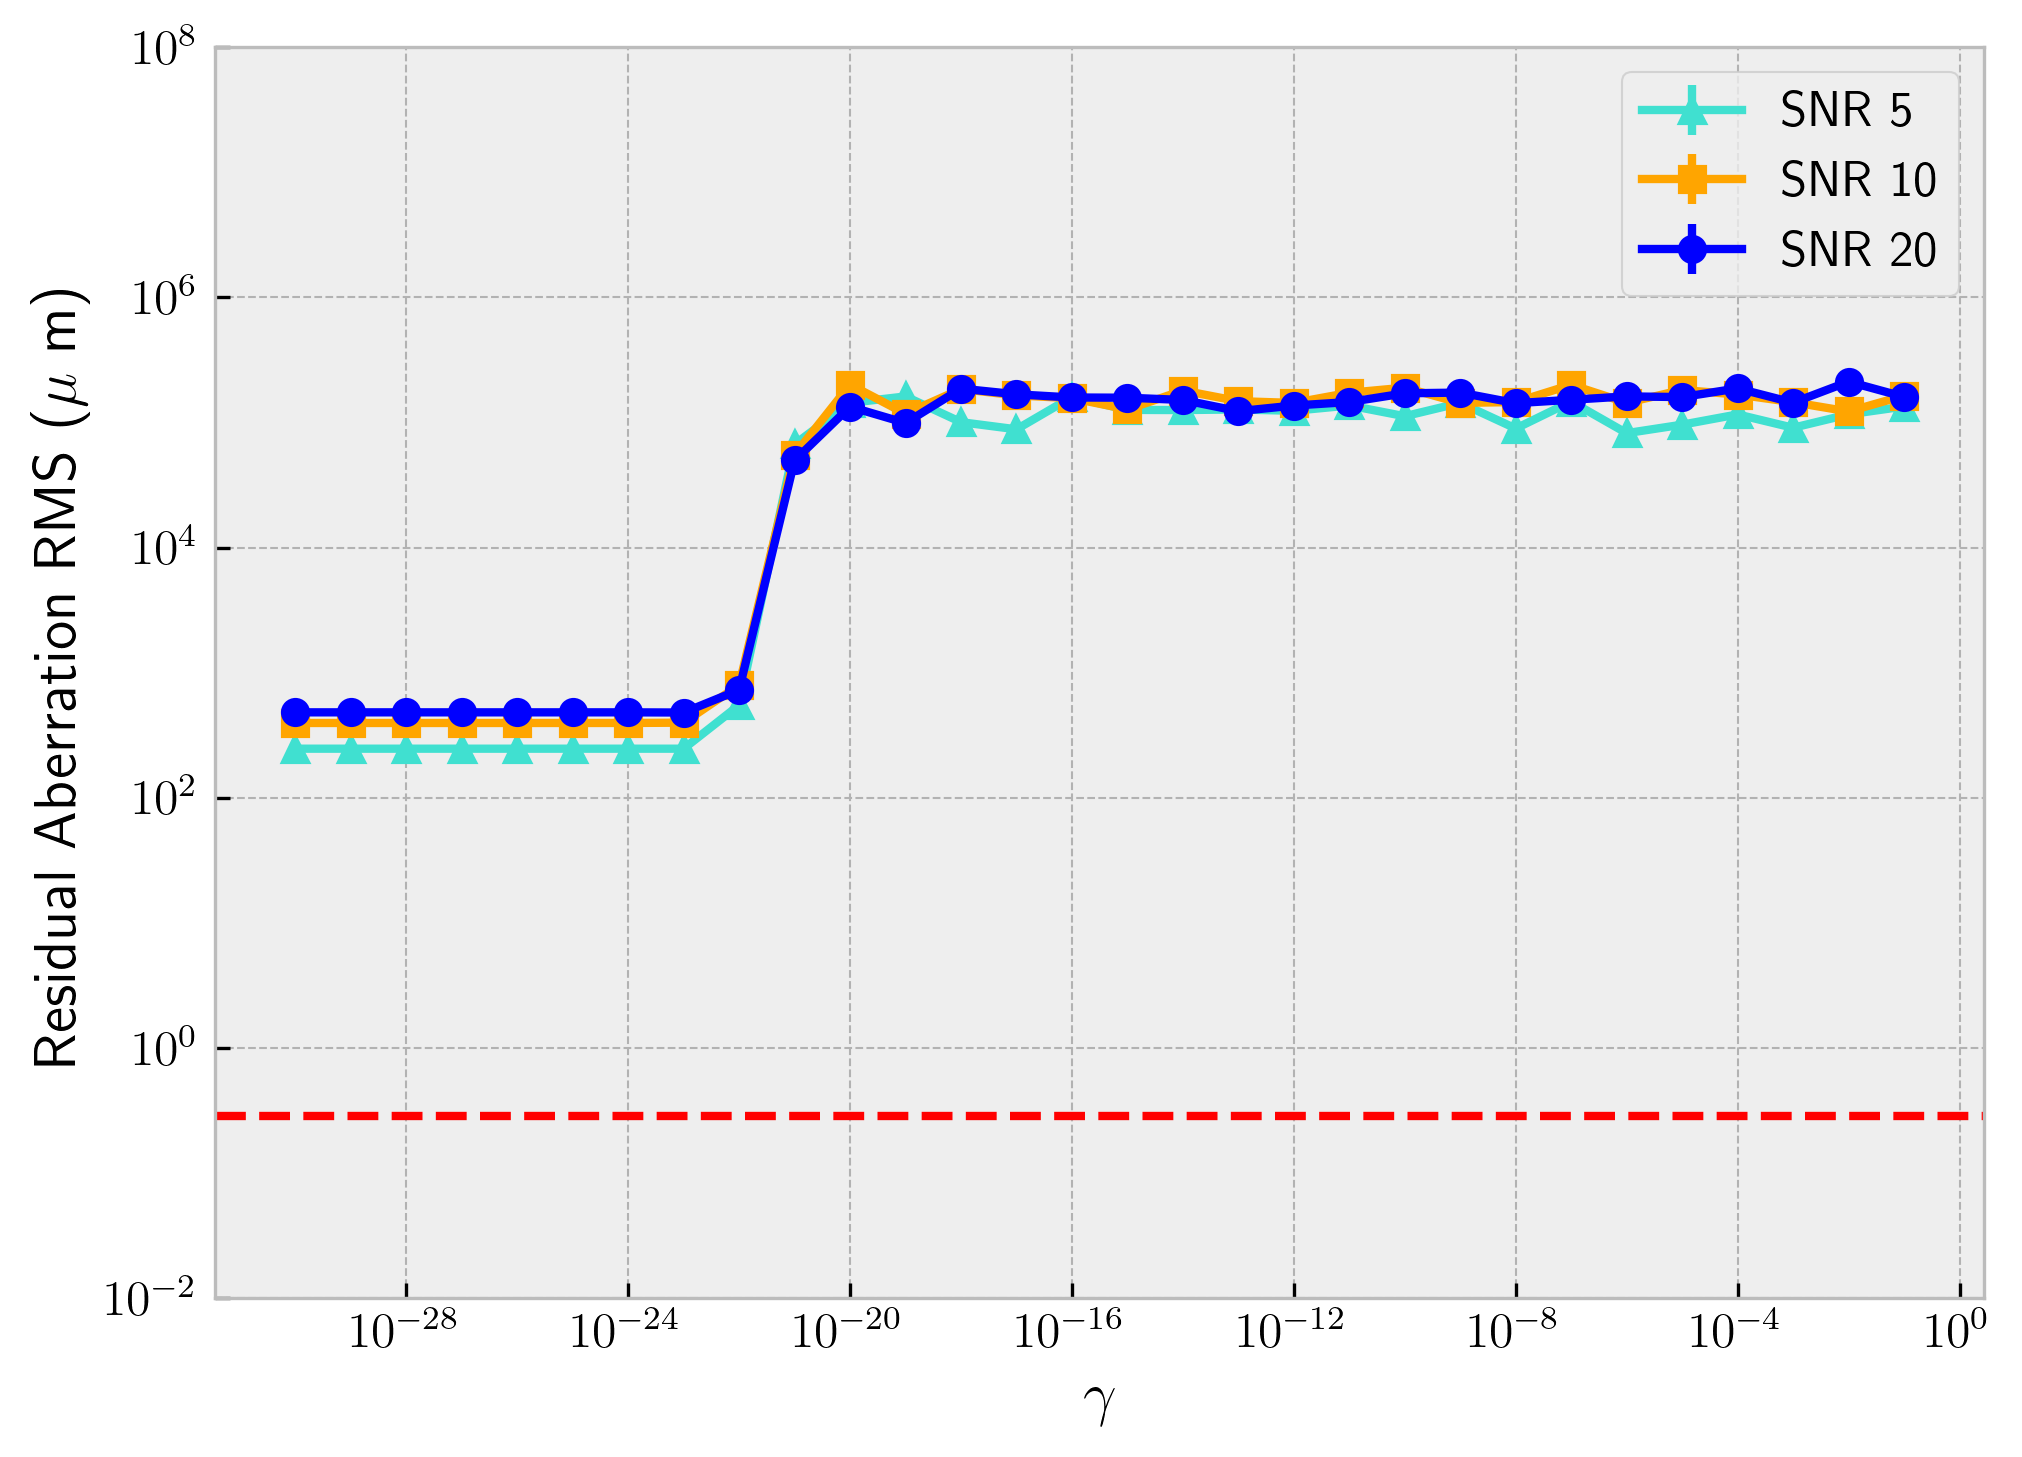

In [60]:
fig, ax = plt.subplots(dpi=300)

colors = ["turquoise", "orange", "blue"]
markers = ["^", "s", "o"]
for j, SNR in enumerate(SNR_vals):
    rms_list = np.zeros((len(gamma_vals), num_samples))

    for k, gamma in enumerate(gamma_vals):
        rms = np.zeros(num_samples)

        for i in range(num_samples):
            this_c_true = c_true[i, j, k]
            this_c_converged = c_converged[i, j, k]

            a_true = Aberration(modes, this_c_true)
            a_converged = Aberration(modes, this_c_converged)

            rms[i] = zernike_RMS_difference(a_true, a_converged, alpha) 

        rms_list[k] = rms * (523/1000)
        #* 523 nm / wv * 1 mum /1000 nm

    ax.errorbar(
        gamma_vals,
        np.mean(rms_list, axis=1),
        np.std(rms_list, axis=1),
        label=f"SNR {SNR}",
        marker = markers[j],
        c = colors[j]
    )

ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("$\gamma$")
ax.set_ylabel("Residual Aberration RMS ($\mu$ m)")
ax.set_ylim(0.01, 100000000)
ax.axhline(zernike_RMS(a_true, alpha), color = "red", ls = "dashed")

In [111]:
c_true = np.load("gamma_results/l_m_c_true_3p.npy")
c_converged = np.load("gamma_results/l_m_c_converged_3p.npy")

In [112]:
np.shape(c_true)

(1, 7, 9, 17)

In [122]:
l_m_vals = [10**(x) for x in range(8, 10)]
gamma_vals = [10**-11, 10**-8, 10**-7, 10**-5]
num_samples = 1

[[5.1795214 ]
 [4.19006785]
 [0.83637361]
 [0.6250995 ]]
[[0.1858952 ]
 [0.15718438]
 [0.16618026]
 [0.17810384]]


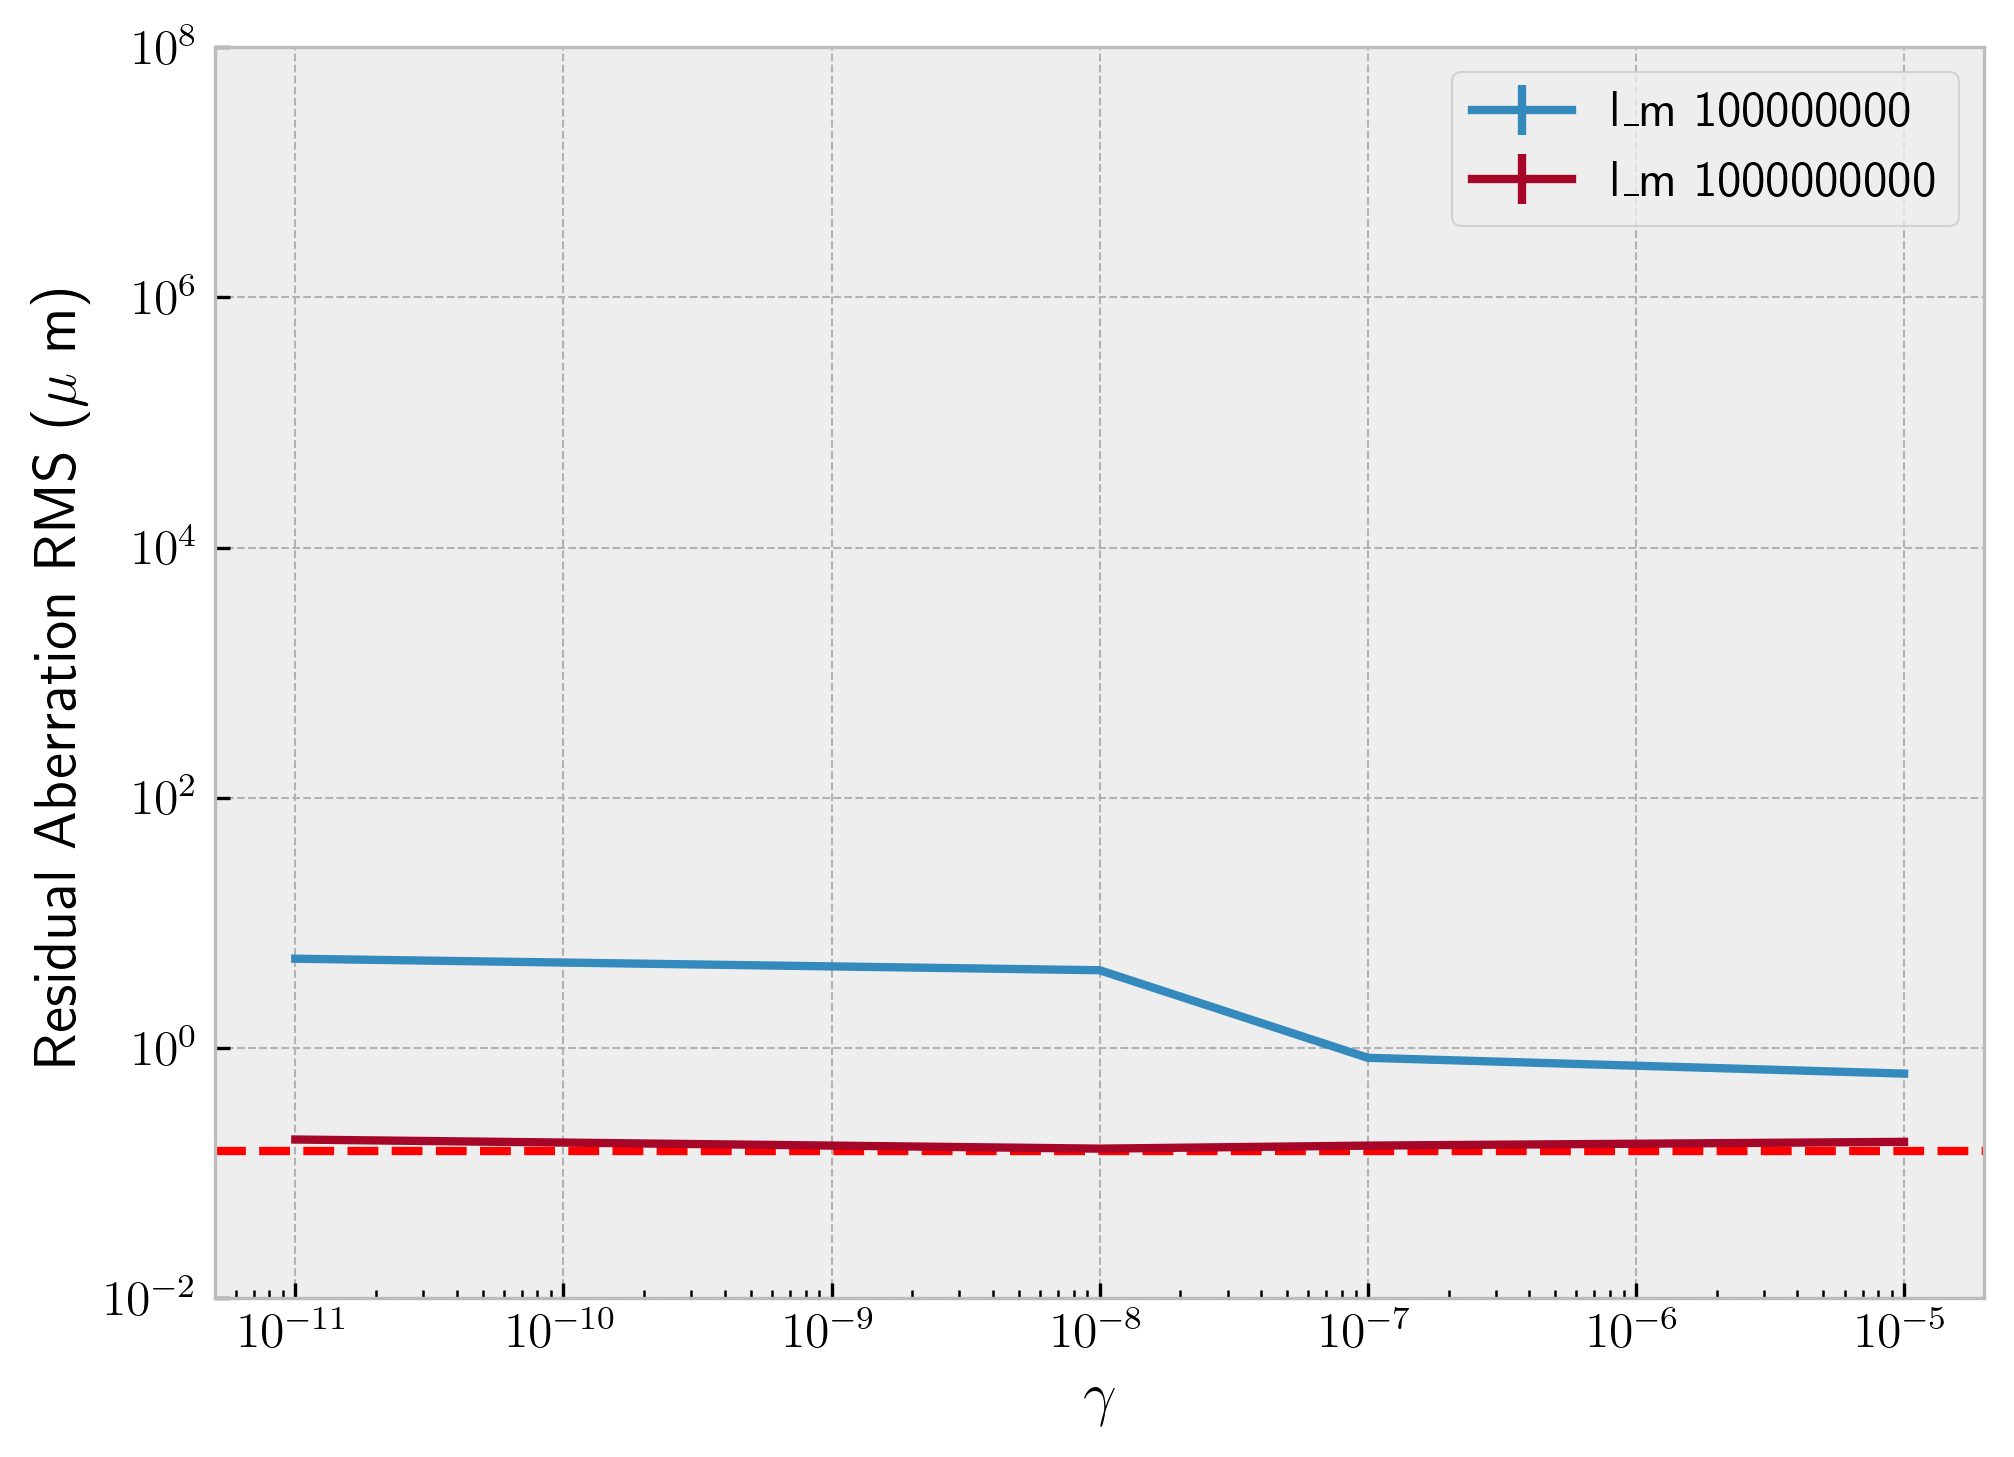

In [123]:
fig, ax = plt.subplots(dpi=300)

for j, l_m in enumerate(l_m_vals):
    rms_list = np.zeros((len(gamma_vals), num_samples))

    for k, gamma in enumerate(gamma_vals):
        rms = np.zeros(num_samples)

        for i in range(num_samples):
            this_c_true = c_true[i, j, k]
            this_c_converged = c_converged[i, j, k]

            a_true = Aberration(modes, this_c_true)
            a_converged = Aberration(modes, this_c_converged)

            rms[i] = zernike_RMS_difference(a_true, a_converged, alpha) 

        rms_list[k] = rms * (523/1000)

        #* 523 nm / wv * 1 mum /1000 nm
    print(rms_list)
    ax.errorbar(
        gamma_vals,
        np.mean(rms_list, axis=1),
        np.std(rms_list, axis=1),
        label=f"l_m {l_m}",
    )

ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("$\gamma$")
ax.set_ylabel("Residual Aberration RMS ($\mu$ m)")
ax.set_ylim(0.01, 100000000)
ax.axhline(zernike_RMS(a_true, alpha) * (523/1000), color = "red", ls = "dashed")

In [129]:
max_steps = [0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]
gamma_vals = [10**(-x) for x in range(1, 31)]
num_samples = 1

c_true = np.load("max_step_c_true.npy")
c_converged = np.load("max_step_c_converged.npy")

[[0.21465308]
 [0.21465253]
 [0.21465324]
 [0.21465259]
 [0.21465329]
 [0.21465323]
 [0.21465409]
 [0.21465343]
 [0.21465245]
 [0.21465367]
 [0.21465244]
 [0.21465559]
 [0.21465291]
 [0.2146538 ]
 [0.21465321]
 [0.21465239]
 [0.21465338]
 [0.21465433]
 [0.21465391]
 [0.21465366]
 [0.21465399]
 [0.21465331]
 [0.21465265]
 [0.21465186]
 [0.21465368]
 [0.1816277 ]
 [0.18162725]
 [0.18162756]
 [       nan]
 [       nan]]
[[0.26326165]
 [0.26376424]
 [0.26402736]
 [0.26452225]
 [0.26371533]
 [0.26344232]
 [0.26337307]
 [0.26361562]
 [0.26328945]
 [0.2652657 ]
 [0.26330666]
 [0.26314379]
 [0.2634073 ]
 [0.26329482]
 [0.26324506]
 [0.26329692]
 [0.26444636]
 [0.26347669]
 [0.26324635]
 [0.26445753]
 [0.26434438]
 [0.26375685]
 [0.26449013]
 [0.26321247]
 [0.25304905]
 [0.23583547]
 [0.23583542]
 [0.23583603]
 [       nan]
 [       nan]]
[[0.31016715]
 [0.31967458]
 [0.30509013]
 [0.30191341]
 [0.33482433]
 [0.31437871]
 [0.3209271 ]
 [0.30282379]
 [0.31044407]
 [0.30681526]
 [0.29809865]
 [0.

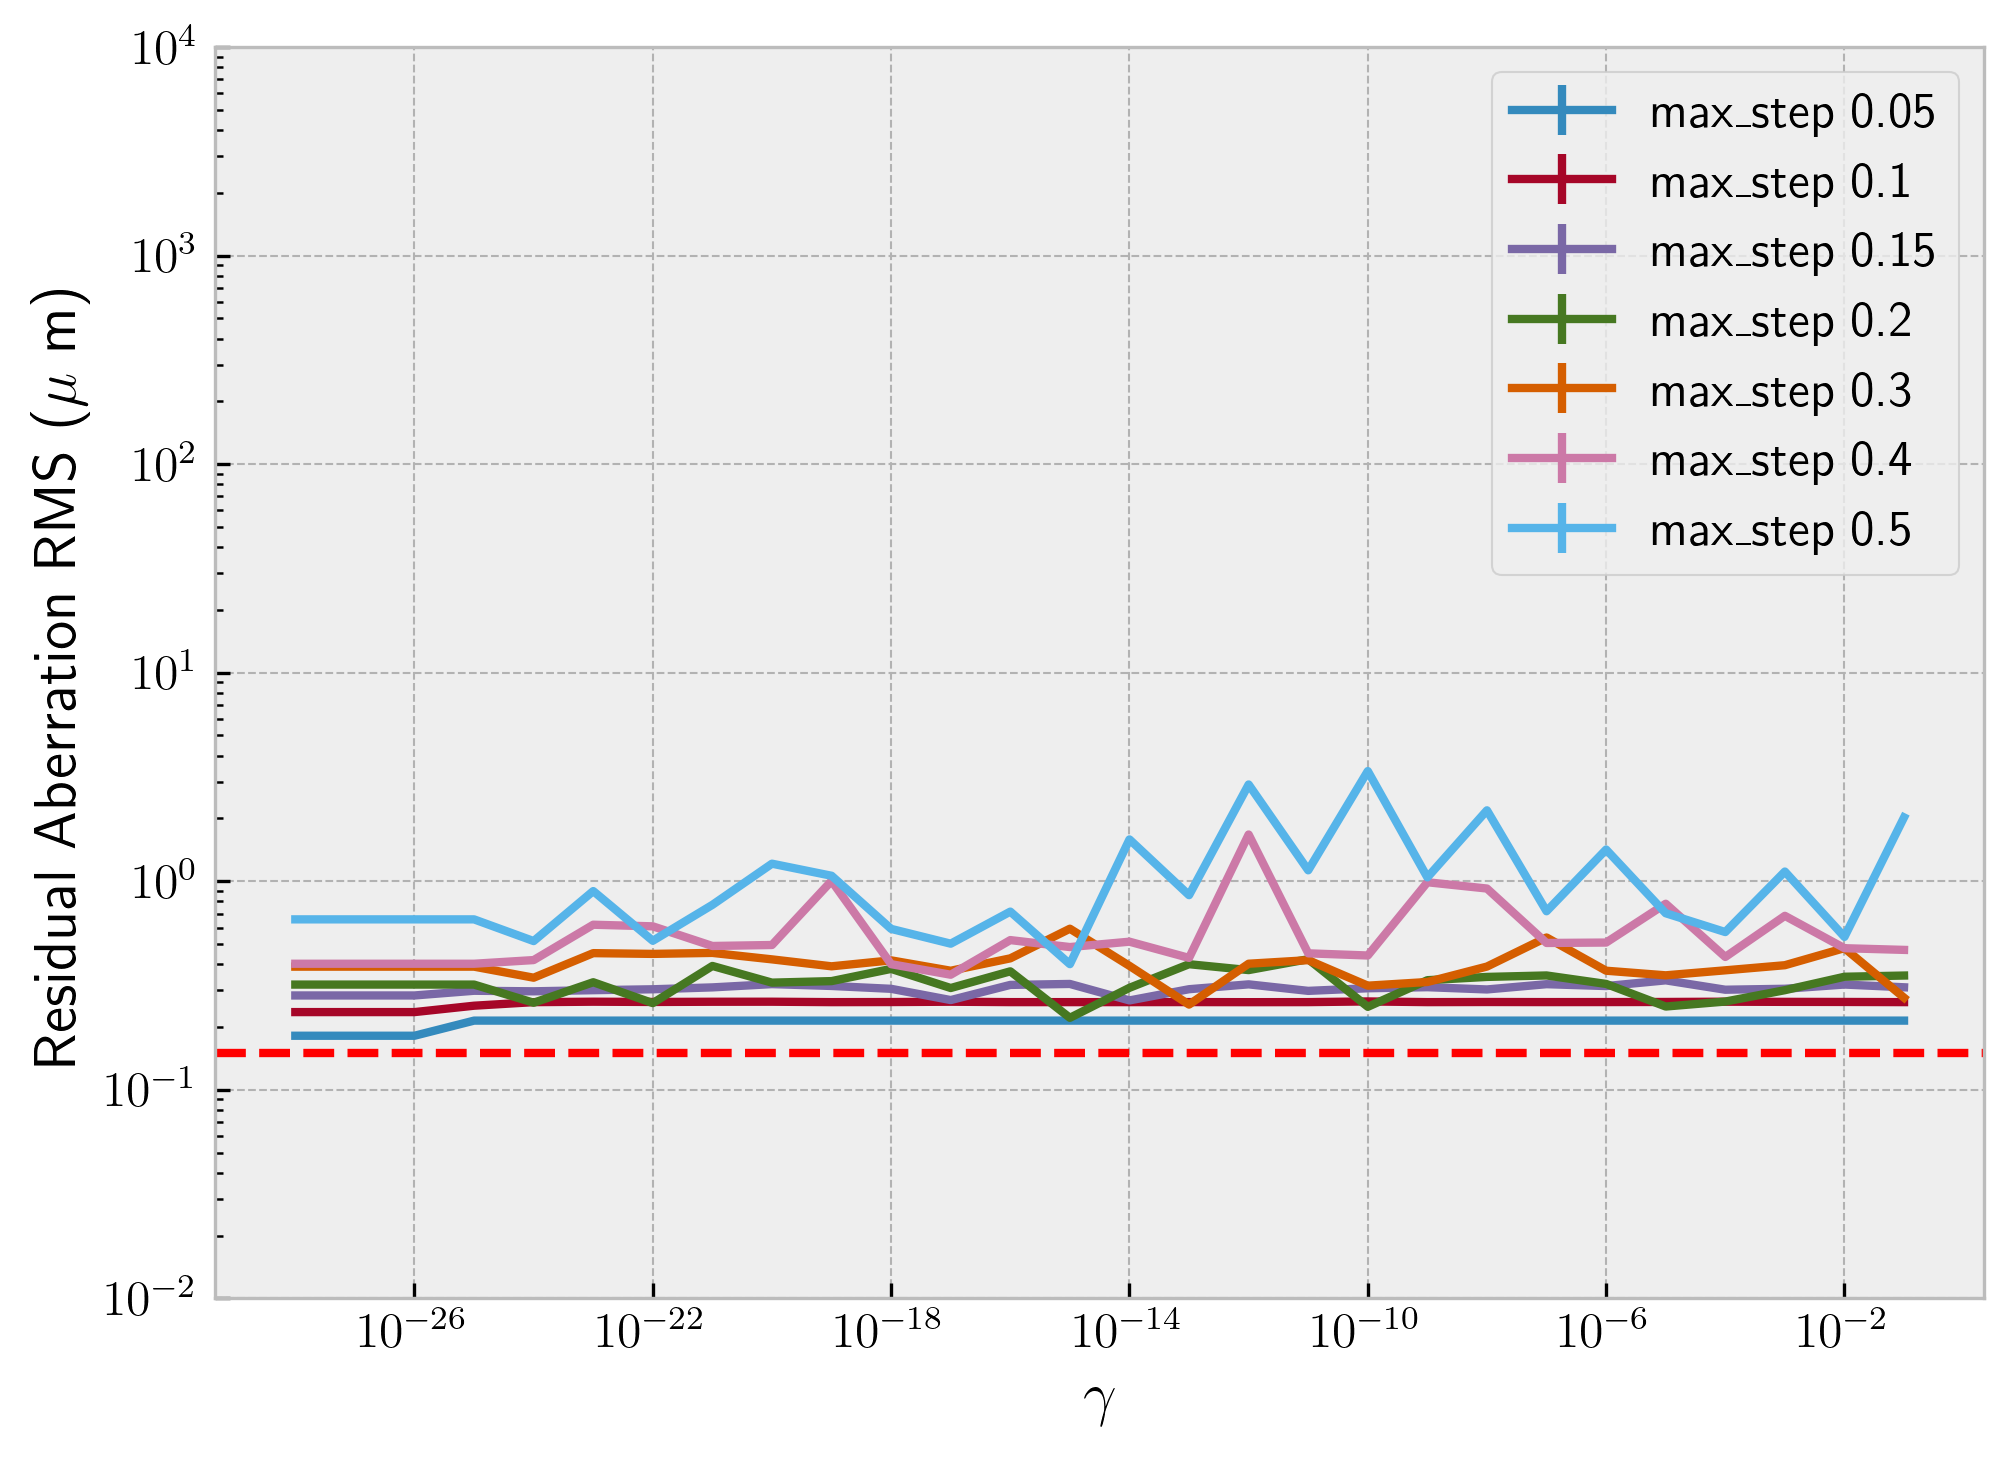

In [133]:
fig, ax = plt.subplots(dpi=300)

for j, max_step in enumerate(max_steps):
    rms_list = np.zeros((len(gamma_vals), num_samples))

    for k, gamma in enumerate(gamma_vals):
        rms = np.zeros(num_samples)

        for i in range(num_samples):
            this_c_true = c_true[i, j, k]
            this_c_converged = c_converged[i, j, k]

            a_true = Aberration(modes, this_c_true)
            a_converged = Aberration(modes, this_c_converged)

            rms[i] = zernike_RMS_difference(a_true, a_converged, alpha) 

        rms_list[k] = rms * (523/1000)

        #* 523 nm / wv * 1 mum /1000 nm
    print(rms_list)
    ax.errorbar(
        gamma_vals,
        np.mean(rms_list, axis=1),
        np.std(rms_list, axis=1),
        label=f"max_step {max_step}",
    )

ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("$\gamma$")
ax.set_ylabel("Residual Aberration RMS ($\mu$ m)")
ax.set_ylim(0.01, 10000)
ax.axhline(zernike_RMS(a_true, alpha) * (523/1000), color = "red", ls = "dashed")